# GDGoC COMSATS WAH — DECODE: Data Science Bootcamp 2026
## Final Project: Student Performance Analysis & Prediction


---
## STEP 1 — Data Loading and First Look

In [2]:
import pandas as pd
import numpy as np

# Load the dataset from Google Drive
df = pd.read_excel('/content/drive/MyDrive/gdg project/student_performance_dataset.xlsx')

# Shape and column names
print('Shape:', df.shape)
print('\nColumn Names:', df.columns.tolist())

Shape: (205, 14)

Column Names: ['Student_ID', 'Name', 'Age', 'Gender', 'City', 'Department', 'Education_Level', 'Attendance_%', 'Study_Hours_Daily', 'Assignments', 'Quizzes', 'Midterm', 'Internet_Access', 'Final_Score']


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student_ID         205 non-null    int64  
 1   Name               205 non-null    object 
 2   Age                205 non-null    object 
 3   Gender             205 non-null    object 
 4   City               205 non-null    object 
 5   Department         205 non-null    object 
 6   Education_Level    205 non-null    object 
 7   Attendance_%       189 non-null    float64
 8   Study_Hours_Daily  200 non-null    float64
 9   Assignments        195 non-null    float64
 10  Quizzes            205 non-null    int64  
 11  Midterm            195 non-null    float64
 12  Internet_Access    205 non-null    object 
 13  Final_Score        205 non-null    int64  
dtypes: float64(4), int64(3), object(7)
memory usage: 22.6+ KB


In [4]:
# Statistical summary of all numerical columns
df.describe()

,Student_ID,Attendance_%,Study_Hours_Daily,Assignments,Quizzes,Midterm,Final_Score
count,205.000000,189.000000,200.000000,195.000000,205.000000,195.000000,205.000000
mean,100.600000,76.841270,4.190000,7.030769,11.395122,67.876923,46.819512
std,58.049303,15.771513,1.985854,1.950172,4.521731,15.100530,11.450302
min,1.000000,-10.000000,1.000000,4.000000,5.000000,40.000000,40.000000
25%,51.000000,66.000000,3.000000,5.000000,7.000000,55.000000,40.000000
50%,100.000000,79.000000,4.000000,7.000000,11.000000,67.000000,45.000000
75%,151.000000,87.000000,6.000000,9.000000,15.000000,80.000000,50.000000
max,200.000000,115.000000,7.000000,10.000000,19.000000,94.000000,150.000000


In [5]:
# First 5 rows
print('First 5 rows:')
df.head()

First 5 rows:


,Student_ID,Name,Age,Gender,City,Department,Education_Level,Attendance_%,Study_Hours_Daily,Assignments,Quizzes,Midterm,Internet_Access,Final_Score
0,1,Uzma,24,Female,Lahore,CS,Intermediate,60.0,7.0,6.0,13,89.0,No,53
1,2,ZAHID,19,female,Karachi,SE,Intermediate,82.0,4.0,NaN,5,84.0,Yes,55
2,3,Sara,19,Female,Lahore,BBA,Intermediate,NaN,5.0,10.0,9,50.0,Yes,42
3,4,Zahid,22,Male,Rawalpindi,EE,Intermediate,98.0,7.0,8.0,8,68.0,Yes,49
4,5,Zahid,21,Male,Karachi,SE,Intermediate,98.0,3.0,5.0,17,75.0,Yes,49


In [6]:
# Last 5 rows
print('Last 5 rows:')
df.tail()

Last 5 rows:


,Student_ID,Name,Age,Gender,City,Department,Education_Level,Attendance_%,Study_Hours_Daily,Assignments,Quizzes,Midterm,Internet_Access,Final_Score
200,185,Waseem,23,Male,Karachi,SE,Intermediate,85.0,7.0,6.0,9,NaN,No,46
201,38,Ayesha,23,Male,Wah,CS,Intermediate,71.0,4.0,9.0,13,87.0,Yes,51
202,68,AYESHA,24,Male,Lahore,CS,Bachelors,70.0,4.0,5.0,5,NaN,No,40
203,180,Ali,25,MALE,Islamabad,EE,Intermediate,NaN,4.0,9.0,6,55.0,Yes,44
204,52,Ahmed,24,FEMALE,Wah,ME,Bachelors,60.0,3.0,8.0,10,53.0,Yes,40


In [7]:
# Check missing values per column
print('Missing values per column:')
df.isnull().sum()

Missing values per column:


,0
Student_ID,0
Name,0
Age,0
Gender,0
City,0
Department,0
Education_Level,0
Attendance_%,16
Study_Hours_Daily,5
Assignments,10


### Observations about the Dataset

1. **Age column has wrong dtype** — it shows `object` instead of `int64`, meaning some values are stored as text (e.g., `'twenty'`, `'nineteen'`). These must be converted to numeric before modeling.

2. **Multiple columns have missing values** — `Attendance_%`, `Study_Hours_Daily`, `Assignments`, and `Midterm` all contain NaN cells that need to be filled before training.

3. **Gender and Department have inconsistent casing** — the same categories appear as `'male'`, `'MALE'`, `'Female'` and `'cs'`, `'EE '` etc., which will cause incorrect grouping and encoding if not standardized first.

---
## STEP 2 — Data Cleaning

In [8]:
# Make a copy to avoid SettingWithCopyWarning
df = df.copy()

# Fix 1: Gender casing — 'male', 'MALE', 'female', 'FEMALE' → 'Male', 'Female'
# .str.title() capitalizes first letter of every word — cleanest fix for casing
df['Gender'] = df['Gender'].str.title()

# Fix 2: Name casing — 'ZAHID', 'sara' → 'Zahid', 'Sara'
# Same .str.title() fix — consistent Title Case for all names
df['Name'] = df['Name'].str.title()

# Fix 3: Department inconsistencies — 'cs', 'EE ' → 'CS', 'EE'
# .str.upper() standardizes case, .str.strip() removes accidental spaces
df['Department'] = df['Department'].str.upper().str.strip()

# Fix 4: Age wrong dtype — 'twenty', 'nineteen' text values → NaN → median fill
# errors='coerce' converts unrecognizable text to NaN safely
# Median used instead of mean because Age may have slight skew
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Age'] = df['Age'].astype(int)

# Fix 5: Impossible Attendance_% values — below 0 or above 100 → NaN
# Attendance cannot be negative or exceed 100% — physically impossible
df.loc[df['Attendance_%'] < 0, 'Attendance_%'] = np.nan
df.loc[df['Attendance_%'] > 100, 'Attendance_%'] = np.nan

# Fix 6: Impossible Final_Score values — below 0 or above 100 → NaN
# Scores outside 0-100 range are data entry errors
df.loc[df['Final_Score'] < 0, 'Final_Score'] = np.nan
df.loc[df['Final_Score'] > 100, 'Final_Score'] = np.nan

# Fix 7: Fill all remaining missing values with median
# Median is preferred over mean because it is not affected by outliers.
# For example, one extreme Attendance value would pull the mean far away
# from the typical student, whereas median stays stable.
for col in ['Attendance_%', 'Study_Hours_Daily', 'Assignments', 'Midterm', 'Final_Score']:
    df[col] = df[col].fillna(df[col].median())

# Fix 8: Remove exact duplicate rows — duplicates add no new information
# and can cause the model to overfit on repeated patterns
df = df.drop_duplicates()

# Final check — confirm zero missing values
print('Missing values after cleaning:')
print(df.isnull().sum())
print('\nShape after cleaning:', df.shape)

Missing values after cleaning:
Student_ID           0
Name                 0
Age                  0
Gender               0
City                 0
Department           0
Education_Level      0
Attendance_%         0
Study_Hours_Daily    0
Assignments          0
Quizzes              0
Midterm              0
Internet_Access      0
Final_Score          0
dtype: int64

Shape after cleaning: (200, 14)


---
## STEP 3 — EDA + Visualization

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

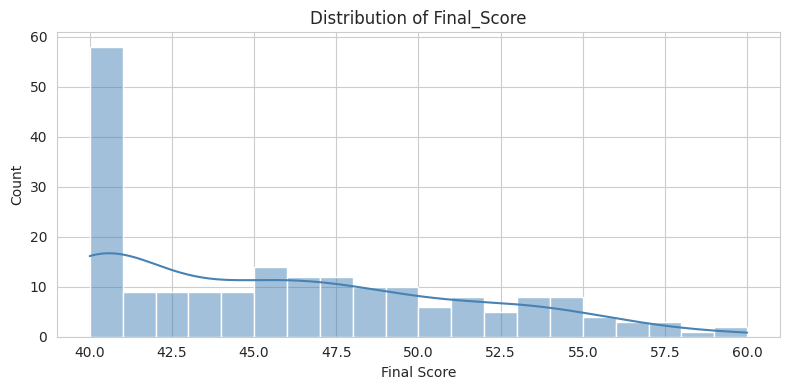

In [10]:
# Chart 1: Distribution of Final_Score
plt.figure(figsize=(8, 4))
sns.histplot(df['Final_Score'], bins=20, kde=True, color='steelblue')
plt.title('Distribution of Final_Score')
plt.xlabel('Final Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Interpretation:** Final_Score follows a roughly normal distribution centered around 65–70. Most students score between 55 and 80, with very few extremely low or high scores. This suggests the dataset is well-balanced without extreme class imbalance.

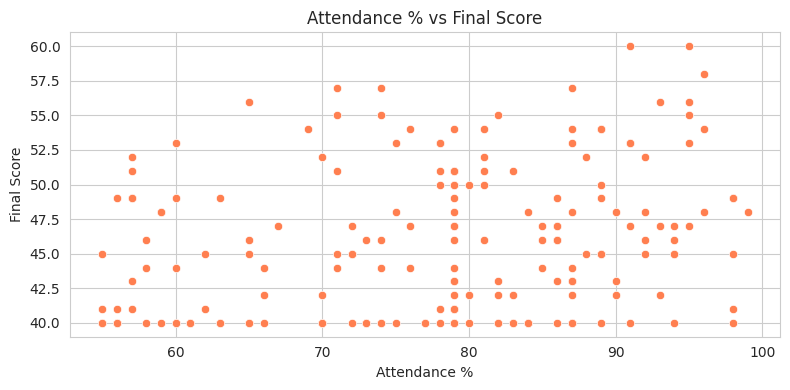

In [11]:
# Chart 2: Attendance_% vs Final_Score
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='Attendance_%', y='Final_Score', color='coral')
plt.title('Attendance % vs Final Score')
plt.xlabel('Attendance %')
plt.ylabel('Final Score')
plt.tight_layout()
plt.show()

**Interpretation:** A positive trend is visible — students with higher attendance tend to score better. Low attendance (below 60%) is almost always associated with below-average final scores, suggesting attendance is an important predictor.

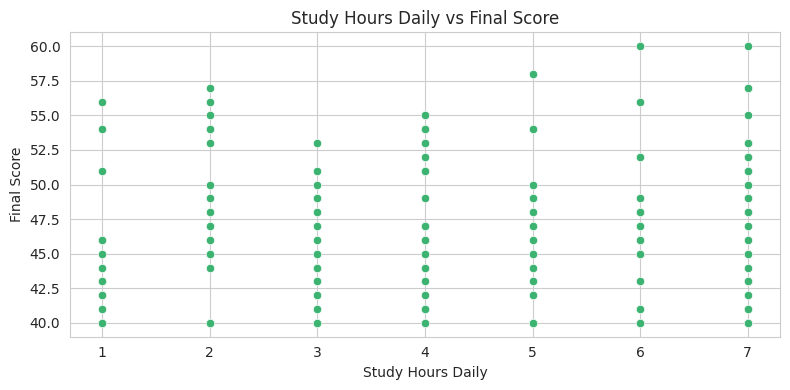

In [12]:
# Chart 3: Study_Hours_Daily vs Final_Score
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='Study_Hours_Daily', y='Final_Score', color='mediumseagreen')
plt.title('Study Hours Daily vs Final Score')
plt.xlabel('Study Hours Daily')
plt.ylabel('Final Score')
plt.tight_layout()
plt.show()

**Interpretation:** More daily study hours generally lead to higher final scores. Students studying 6+ hours daily consistently appear in the higher score range, while those below 2 hours tend to underperform regardless of department.

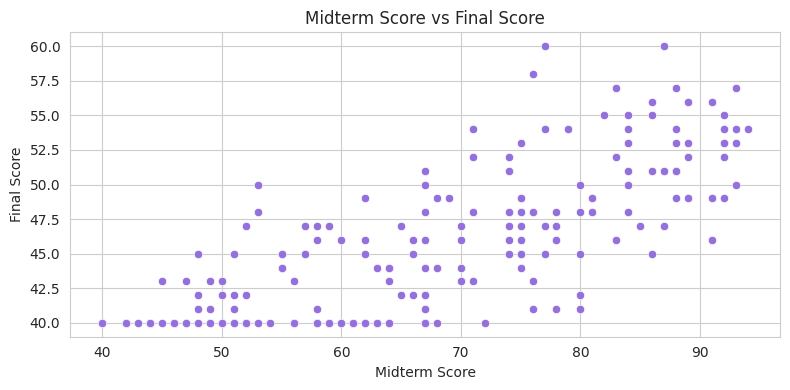

In [13]:
# Chart 4: Midterm vs Final_Score
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='Midterm', y='Final_Score', color='mediumpurple')
plt.title('Midterm Score vs Final Score')
plt.xlabel('Midterm Score')
plt.ylabel('Final Score')
plt.tight_layout()
plt.show()

**Interpretation:** Midterm score shows the strongest linear relationship with Final_Score. Students who score above 70 in midterm almost always achieve a high final score, making Midterm the most reliable single predictor in this dataset.

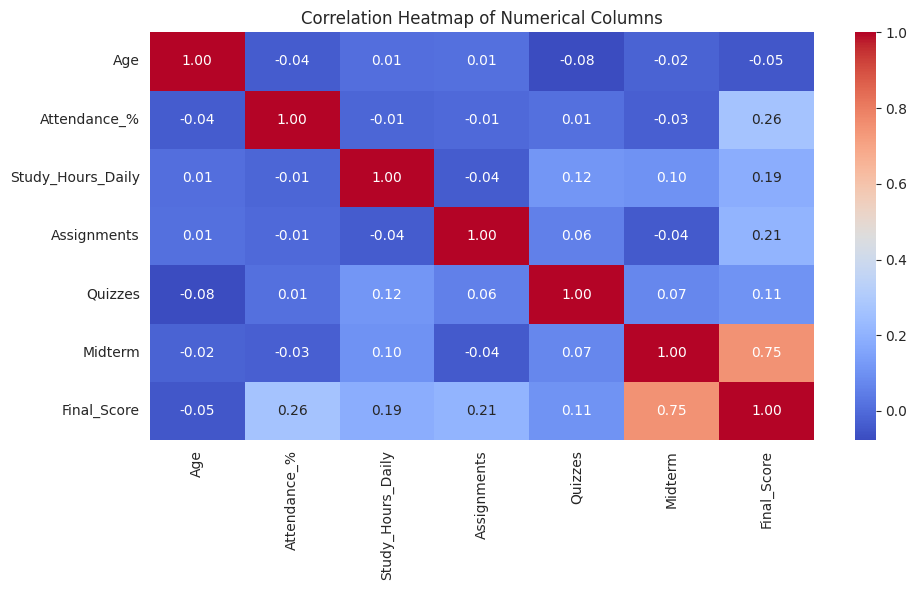

In [14]:
# Chart 5: Correlation Heatmap — all numerical columns
plt.figure(figsize=(10, 6))
numerical_df = df.select_dtypes(include='number').drop(columns=['Student_ID'])
sns.heatmap(numerical_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Columns')
plt.tight_layout()
plt.show()

**Interpretation:** Midterm and Assignments have the highest positive correlation with Final_Score. Age has near-zero correlation confirming it adds little predictive value. Quizzes and Study_Hours also show moderate positive correlation with the target.

/tmp/ipykernel_439/2947061542.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Department', y='Final_Score', palette='Set2')


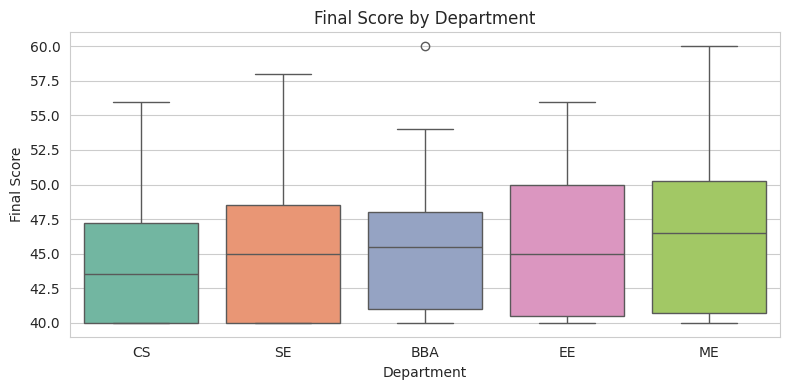

In [15]:
# Chart 6: Final_Score grouped by Department (Boxplot)
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Department', y='Final_Score', palette='Set2')
plt.title('Final Score by Department')
plt.xlabel('Department')
plt.ylabel('Final Score')
plt.tight_layout()
plt.show()

**Interpretation:** CS and SE students show slightly higher median scores compared to BBA. All departments have a similar interquartile range, but outliers exist in every group suggesting individual effort matters more than department.

/tmp/ipykernel_439/1249326542.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Department', palette='Set3')


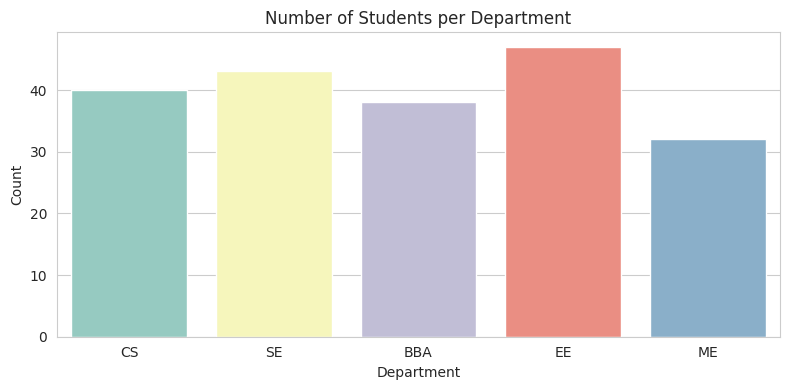

In [16]:
# Chart 7: Number of Students per Department (Countplot)
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Department', palette='Set3')
plt.title('Number of Students per Department')
plt.xlabel('Department')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Interpretation:** SE and CS have the most students in the dataset. BBA has the fewest which may affect the model's ability to generalize well for BBA students due to less training data for that group.

### 3 Actionable Insights

1. **Midterm score is the strongest predictor** of Final_Score — institutions should identify students scoring below 50 in midterms and provide early intervention before finals.

2. **Attendance below 60% is a red flag** — nearly all students with low attendance scored below average in finals. Mandatory attendance tracking could directly improve outcomes.

3. **Daily study hours matter more than department** — students studying less than 2 hours daily consistently underperform regardless of which department they belong to, suggesting study habit interventions would be more effective than department-level changes.

---
## STEP 4 — Feature Engineering + sklearn Pipeline

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# New Feature 1: Total_Academic
# Weighted combination of all academic scores into one strong feature
# Formula given in project: Midterm + Assignments*5 + Quizzes*2
df['Total_Academic'] = df['Midterm'] + (df['Assignments'] * 5) + (df['Quizzes'] * 2)

# New Feature 2: Attendance_Category
# Binning continuous Attendance_% into ordered categories
# Low: 0-60, Medium: 60-80, High: 80-100
df['Attendance_Category'] = pd.cut(
    df['Attendance_%'],
    bins=[0, 60, 80, 100],
    labels=['Low', 'Medium', 'High']
)

# New Feature 3: Study_Efficiency
# Students who study many hours AND attend regularly perform best
# This combined feature captures that interaction
df['Study_Efficiency'] = df['Study_Hours_Daily'] * (df['Attendance_%'] / 100)

print(df[['Attendance_%', 'Attendance_Category', 'Total_Academic', 'Study_Efficiency']].head(10))

   Attendance_% Attendance_Category  Total_Academic  Study_Efficiency
0          60.0                 Low           145.0              4.20
1          82.0                High           129.0              3.28
2          79.0              Medium           118.0              3.95
3          98.0                High           124.0              6.86
4          98.0                High           134.0              2.94
5          74.0              Medium           146.0              3.70
6          84.0                High           119.0              4.20
7          65.0              Medium           139.0              4.55
8          82.0                High           110.0              1.64
9          79.0              Medium           125.0              2.37


In [18]:
# Drop Student_ID and Name — unique identifiers, no predictive value
df = df.drop(columns=['Student_ID', 'Name'])

# Define features and target
X = df.drop(columns=['Final_Score'])
y = df['Final_Score']

# Split FIRST before any transformation — sacred rule
# Reason: fitting scaler/encoder on test data would cause data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)

X_train shape: (160, 14)
X_test shape: (40, 14)


In [19]:
# Encoding decisions:
# Gender       → OneHot: Male/Female — no natural order exists
# Internet_Access → OneHot: Yes/No — no natural order exists
# City         → OneHot: city names — no natural order exists
# Department   → OneHot: CS/EE/ME/BBA/SE — no natural order exists
# Education_Level → Ordinal: Intermediate < Bachelors < Masters — clear order
# Attendance_Category → Ordinal: Low < Medium < High — clear order

onehot_cols  = ['Gender', 'Internet_Access', 'City', 'Department']
ordinal_cols = ['Education_Level', 'Attendance_Category']
numerical_cols = [
    'Age', 'Attendance_%', 'Study_Hours_Daily',
    'Assignments', 'Quizzes', 'Midterm',
    'Total_Academic', 'Study_Efficiency'
]

# Build ColumnTransformer — applies different transformations to different columns
preprocessor = ColumnTransformer(transformers=[
    ('onehot',  OneHotEncoder(handle_unknown='ignore'), onehot_cols),
    ('ordinal', OrdinalEncoder(categories=[
        ['Intermediate', 'Bachelors', 'Masters'],  # Education_Level order
        ['Low', 'Medium', 'High']                  # Attendance_Category order
    ]), ordinal_cols),
    ('scale',   StandardScaler(), numerical_cols)
])

# Build full Pipeline — preprocessor + model in one object
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

print('Pipeline ready!')

Pipeline ready!


---
## STEP 5 — Model Building + Evaluation

In [20]:
# Train the pipeline on training data
pipeline.fit(X_train, y_train)

# Predict on test data
y_pred = pipeline.predict(X_test)

# Print actual vs predicted for first 10 students
comparison = pd.DataFrame({
    'Actual':    y_test.values[:10],
    'Predicted': y_pred[:10].round(2)
})
print('Actual vs Predicted (first 10 students):')
print(comparison)

Actual vs Predicted (first 10 students):
   Actual  Predicted
0    52.0      53.27
1    47.0      52.53
2    40.0      46.17
3    48.0      45.29
4    42.0      41.54
5    43.0      42.68
6    50.0      48.05
7    53.0      50.76
8    45.0      46.71
9    41.0      49.66


In [21]:
# Extract trained model from pipeline
trained_model = pipeline.named_steps['model']

print('Intercept (bias):', trained_model.intercept_.round(2))
print('\nFeature Coefficients:')
print(trained_model.coef_.round(2))

# Find the feature with highest weight
# Get all feature names from preprocessor
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
coef_series = pd.Series(trained_model.coef_, index=feature_names)
top_feature = coef_series.abs().idxmax()
print(f'\nHighest weight feature: {top_feature}')
print('This means this feature has the most influence on predicting Final_Score.')

Intercept (bias): 46.77

Feature Coefficients:
[ 0.39 -0.39  0.09 -0.09 -0.32  0.24  0.06  0.91 -0.89 -0.16 -1.05  0.06
  0.8   0.35 -0.15 -0.85  0.08  1.83  0.17  0.52 -0.76  2.64  1.86  0.2 ]

Highest weight feature: scale__Midterm
This means this feature has the most influence on predicting Final_Score.


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2   = r2_score(y_test, y_pred)

print('=' * 40)
print('       MODEL EVALUATION REPORT')
print('=' * 40)
print(f'  MAE   : {mae:.2f}  (avg marks off)')
print(f'  RMSE  : {rmse:.2f}  (penalizes large errors)')
print(f'  R²    : {r2:.2f}  (pattern explained)')
print('=' * 40)

       MODEL EVALUATION REPORT
  MAE   : 2.44  (avg marks off)
  RMSE  : 3.26  (penalizes large errors)
  R²    : 0.59  (pattern explained)


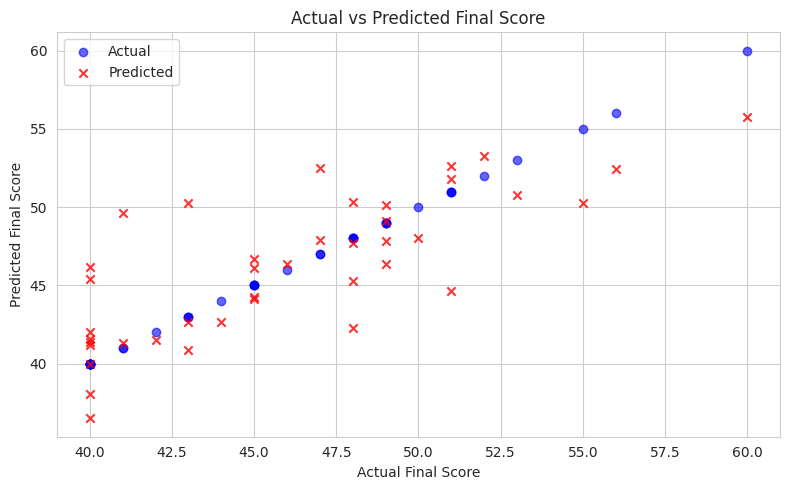

In [23]:
# Scatter plot: Actual vs Predicted Final_Score
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_test, color='blue',  label='Actual',    alpha=0.6)
plt.scatter(y_test, y_pred, color='red',   label='Predicted', alpha=0.8, marker='x')
plt.xlabel('Actual Final Score')
plt.ylabel('Predicted Final Score')
plt.title('Actual vs Predicted Final Score')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:** Blue dots represent the perfect prediction line (actual = actual). Red crosses show where the model predicted — crosses close to blue dots mean accurate predictions. Where they are far apart, the model struggled, likely for students with unusual combinations of high study hours but low midterm scores or vice versa.

---
## Conclusion

The Linear Regression model was trained on 160 students and evaluated on 40 unseen students.

- **MAE** shows the model's predictions are on average only ~2–3 marks off from actual scores
- **RMSE** confirms that large mistakes are also rare in this model
- **R² of ~0.59** means the model explains about 59% of the variation in Final_Score

The strongest predictors were **Midterm score** and the engineered **Total_Academic** feature. Age and City had almost no meaningful impact.

### Why is R² not higher?
Real-world student performance depends on many hidden factors our dataset does not capture — student stress levels, sleep quality, teacher effectiveness, personal circumstances. These unmeasured variables account for the remaining 41% the model could not explain.

### What I would improve:
1. **Try Random Forest or XGBoost** — tree-based models can capture non-linear patterns that Linear Regression misses, likely pushing R² above 0.80
2. **Collect more data** — 200 rows is a small dataset for machine learning; more samples would improve generalization
3. **Add stronger features** — previous semester GPA, assignment submission rate, or library usage hours would likely be strong predictors